In [1]:
# %%
import lightgbm
import pandas as pd
import numpy as np
import glob
import random
import seaborn as sns
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import lleaves

# Remove the model files
import os
import sys
glob_pattern = "data/bc-kron.sg.log"
all_files = glob.glob(glob_pattern)

file = all_files[0]

df_files = [file]
workload = file.split("/")[-1].split(".log")[0]

dfs = []
for f in df_files:

    #df_local = pd.read_csv(f, on_bad_lines="warn", nrows=100_000_000)
    df_local = pd.read_csv(f, on_bad_lines="warn", engine="pyarrow")
    if len(df_local.index) > 10_000_000:
        df_local = df_local.sample(10_000_000)
    df_local["source"] = f

    # print(f"{f[:-4]}.sampled.txt")
    # df_local.to_csv(f"{f[:-4]}.sampled.txt", index=False)

    dfs.append(df_local)

source_lens = [len(df) for df in dfs]

if len(source_lens) == 0:
    print("No valid data files found, skipping workload:", workload)

min_length = min(source_lens)
print("Min length:", min_length)

total_samples = sum(source_lens)
print("Total samples:", total_samples)

train_df = pd.concat([df.assign(weight=min_length / len(df)) for df in dfs])

# %% [markdown]
# import seaborn as sns
#
# import matplotlib.pyplot as plt
#
# df_heat = train_df[train_df["step"] < 200]
# pivot = df_heat.pivot_table(index="page", columns="step", values="discounted_reward_0.90")
# plt.figure(figsize=(12, 8))
# sns.heatmap(pivot, cmap="viridis", vmin=0, vmax=50)
# plt.title("Heatmap of count (intensity) for /cc_out.txt")
# plt.xlabel("step")
# plt.ylabel("page")
# plt.tight_layout()
# plt.show()

# %%
train_df = train_df.merge(
    (train_df.groupby("source")["step"].max() * 0.7).reset_index(),
    on=["source"],
    how="left",
    suffixes=("", "_split"),
)

# %%
# shuffle
train_df = train_df.sample(frac=1, random_state=42).reset_index(drop=True)

for col in train_df.columns:
    if col != "source" and col != "page" and col != "step":
        train_df[col] = train_df[col].astype("float64")
        # sampled_train_df[col] = sampled_train_df[col].astype("float64")

Min length: 10000000
Total samples: 10000000


In [ ]:
train_df["group_neg_mean_perc"] = train_df["group_-1_mean_perc"] + train_df["group_-2_mean_perc"] + train_df["group_-3_mean_perc"]
train_df["group_pos_mean_perc"] = train_df["group_1_mean_perc"] + train_df["group_2_mean_perc"] + train_df["group_3_mean_perc"]

train_df["group_neg_mean_ewma5_perc"] = train_df["group_-1_mean_ewma5_perc"] + train_df["group_-2_mean_ewma5_perc"] + train_df["group_-3_mean_ewma5_perc"]
train_df["group_pos_mean_ewma5_perc"] = train_df["group_1_mean_ewma5_perc"] + train_df["group_2_mean_ewma5_perc"] + train_df["group_3_mean_ewma5_perc"]

train_df["slope1"] = train_df["ewma_5_perc"] / train_df["ewma_20_perc"]
train_df["slope2"] = train_df["ewma_2_perc"] / train_df["ewma_100_perc"]
train_df["slope3"] = train_df["ewma_2_perc"] / train_df["global_avg_accesses_perc"]
train_df["slope4"] = train_df["ewma_5_perc"] / train_df["global_avg_accesses_perc"]

train_df["gap1"] = train_df["ewma_5_perc"] - train_df["ewma_20_perc"]
train_df["gap2"] = train_df["ewma_2_perc"] - train_df["ewma_100_perc"]
train_df["gap3"] = train_df["ewma_2_perc"] - train_df["global_avg_accesses_perc"]
train_df["gap4"] = train_df["ewma_5_perc"] - train_df["global_avg_accesses_perc"]

train_df["read_write_gap1"] = train_df["ewma_5_r_perc"] - train_df["ewma_5_w_perc"]
train_df["read_write_gap2"] = train_df["ewma_20_r_perc"] - train_df["ewma_20_w_perc"]

train_df["gap4"] = train_df["ewma_5_perc"] - train_df["global_avg_accesses_perc"]
train_df["read_write_gap3"] = train_df["ewma_100_r_perc"] - train_df["ewma_100_w_perc"]

train_df["read_write_ratio1"] = train_df["ewma_5_r_perc"] / (train_df["ewma_5_r_perc"] + train_df["ewma_5_w_perc"] + 1e-6)
train_df["read_write_ratio2"] = train_df["ewma_20_r_perc"] / (train_df["ewma_20_r_perc"] + train_df["ewma_20_w_perc"] + 1e-6)
train_df["read_write_ratio3"] = train_df["ewma_100_r_perc"] / (train_df["ewma_100_r_perc"] + train_df["ewma_100_w_perc"] + 1e-6)

local_train_df = train_df

In [4]:
list(train_df.columns)

['step',
 'page',
 'read',
 'write',
 'count',
 'global_avg_accesses',
 'global_avg_accesses_perc',
 'ewma_2_perc',
 'ewma_2_r_perc',
 'ewma_2_w_perc',
 'ewma_5_perc',
 'ewma_5_r_perc',
 'ewma_5_w_perc',
 'ewma_20_perc',
 'ewma_20_r_perc',
 'ewma_20_w_perc',
 'ewma_100_perc',
 'ewma_100_r_perc',
 'ewma_100_w_perc',
 'ewma_var_2',
 'ewma_var_5',
 'ewma_var_20',
 'ewma_var_100',
 'ewma_100_malloc_perc',
 'global_count_since_top1_percent_ewma5',
 'global_count_since_top50_percent_ewma5',
 'group_-7_mean_ewma5_perc',
 'group_-7_mean_perc',
 'group_-7_malloc_calls',
 'group_-7_malloc_calls_perc',
 'group_-7_malloc_calls_ewma100_perc',
 'group_-6_mean_ewma5_perc',
 'group_-6_mean_perc',
 'group_-6_malloc_calls',
 'group_-6_malloc_calls_perc',
 'group_-6_malloc_calls_ewma100_perc',
 'group_-5_mean_ewma5_perc',
 'group_-5_mean_perc',
 'group_-5_malloc_calls',
 'group_-5_malloc_calls_perc',
 'group_-5_malloc_calls_ewma100_perc',
 'group_-4_mean_ewma5_perc',
 'group_-4_mean_perc',
 'group_-4_mal

In [ ]:
features = [
    "ewma_5_perc",
    "ewma_20_perc",
    "ewma_100_perc",
    # "ewma_5_w_perc",
    # "ewma_20_w_perc",
    # "ewma_100_w_perc",
    #"ewma_5_r_perc",
    #"ewma_20_r_perc",
    #"ewma_100_r_perc",
    "global_avg_accesses_perc",
    "group_neg_mean_perc",
    "group_pos_mean_perc",
    "group_0_mean_perc",
    #"ewma_100_malloc_perc",
    #"slope1",
    #"slope2",
    #"slope3",
    #"slope4",
    #"gap1",
    #"gap2",
    #"gap3",
    "gap4",
    #"group_0_malloc_calls_ewma100_perc",
    
    #"read_write_gap1",
    #"read_write_gap2",
    "read_write_gap3",
    #'ewma_var_2',
    #'ewma_var_5',
    #'ewma_var_20',
    'ewma_var_100',
    "group_ewma5_var"
]

OBJECTIVE_COL = "discounted_reward_95"
objective_col = OBJECTIVE_COL
X = local_train_df[features]
W = local_train_df["weight"]
y = local_train_df[objective_col].clip(lower=0).fillna(0)

X_train = X[local_train_df["step"] < local_train_df["step_split"]]
X_test = X[local_train_df["step"] >= local_train_df["step_split"]]
W_train = W[local_train_df["step"] < local_train_df["step_split"]]
W_test = W[local_train_df["step"] >= local_train_df["step_split"]]
y_train = y[local_train_df["step"] < local_train_df["step_split"]]
y_test = y[local_train_df["step"] >= local_train_df["step_split"]]

data = lightgbm.Dataset(X_train, label=y_train, weight=W_train)
data_full = lightgbm.Dataset(X, label=y, weight=W)

best_model = None
best_model_p25 = None
best_model_p75 = None
best_rmse = float("inf")

max_depth = 8
num_iterations = 50
feature_fraction = 1
num_leaves = 25
reg_sqrt = False
lr = 0.25
extra_trees = False
params = {
    "verbosity": -1,
    "boosting_type": "dart",
    "data_sample_strategy": "goss",
    #"l1_regularization": 1000,
    #"l2_regularization": 1000,
    "feature_fraction": feature_fraction,
    "learning_rate": lr,
    "max_bin": 2 ** 14 - 1,
    "max_depth": max_depth,
    # "min_data_in_leaf": 800,
    "min_gain_to_split": 100,
    "num_iterations": num_iterations,
    "num_leaves": num_leaves,
    # "path_smooth": 1000,
    "reg_sqrt": reg_sqrt,
    "extra_trees": extra_trees,
}
                            
model = lightgbm.train(
    params={
        "objective": "regression",
        "metric": "l2"
    } | params,
    train_set=data,
)
                
# Predict using the trained model
y_pred = np.asarray(model.predict(X_test)).ravel()

rmse = root_mean_squared_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
print(f"Test RMSE: {rmse:.4f}")
print(f"Test MAE: {mean_absolute_error(y_test, y_pred):.4f}")
print(f"Test MAPE: {mape:.4f}")
print(f"R^2: {r2_score(y_test, y_pred):.4f}")

group_metrics = []

feature_importances = sorted(
    zip(
        model.feature_importance(),
        model.feature_importance(importance_type="gain"),
        model.feature_name(),
    ),
    key=lambda x: x[1],
    reverse=True,
)
list(feature_importances)

Test RMSE: 198.9304
Test MAE: 13.7730
Test MAPE: 2677284149246723.5000
R^2: 0.9543


[(np.int32(143), np.float64(17301530779260.0), 'ewma_100_perc'),
 (np.int32(135), np.float64(3519426979860.0), 'ewma_var_100'),
 (np.int32(82), np.float64(2124732591744.0), 'group_neg_mean_perc'),
 (np.int32(175), np.float64(1064439088548.0), 'global_avg_accesses_perc'),
 (np.int32(108), np.float64(245952907752.0), 'ewma_20_perc'),
 (np.int32(120), np.float64(218846532420.0), 'group_ewma5_var'),
 (np.int32(87), np.float64(180373222072.0), 'ewma_5_perc'),
 (np.int32(42), np.float64(79256143768.0), 'group_pos_mean_perc'),
 (np.int32(92), np.float64(41517404032.0), 'read_write_gap3'),
 (np.int32(112), np.float64(18888315092.0), 'group_0_mean_perc'),
 (np.int32(104), np.float64(13247510796.0), 'gap4')]

In [10]:
graph_df = local_train_df.loc[local_train_df["step"] >= local_train_df["step_split"]]
graph_df.loc[:, "y_true"] = y_test
graph_df.loc[:, "y_pred"] = y_pred
graph_df.columns

/tmp/ipykernel_3207913/2447470135.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  graph_df.loc[:, "y_true"] = y_test
/tmp/ipykernel_3207913/2447470135.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  graph_df.loc[:, "y_true"] = y_test
/tmp/ipykernel_3207913/2447470135.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented f

Index(['step', 'page', 'read', 'write', 'count', 'global_avg_accesses',
       'global_avg_accesses_perc', 'ewma_2_perc', 'ewma_2_r_perc',
       'ewma_2_w_perc',
       ...
       'gap3', 'gap4', 'read_write_gap1', 'read_write_gap2', 'read_write_gap3',
       'read_write_ratio1', 'read_write_ratio2', 'read_write_ratio3', 'y_true',
       'y_pred'],
      dtype='object', length=138)

In [11]:
def save_heatmap(pivot_df, title, vmin=None, vmax=None, norm=None, facecolor="white"):
    print(title)
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.heatmap(pivot_df, cmap="YlOrRd", annot=False, vmin=vmin, vmax=vmax, norm=norm, ax=ax)
    ax.set_title(title)
    ax.set_facecolor(facecolor)

y_pred
y_true


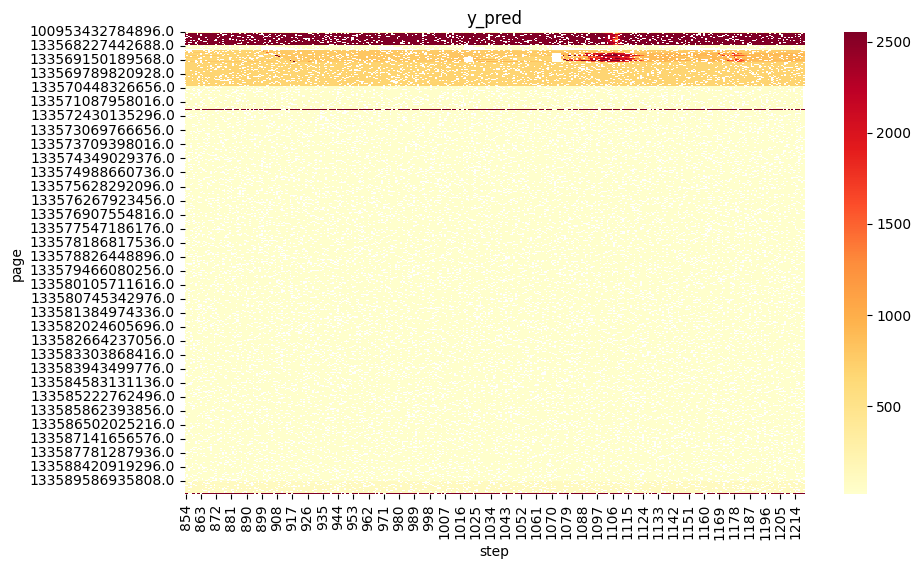

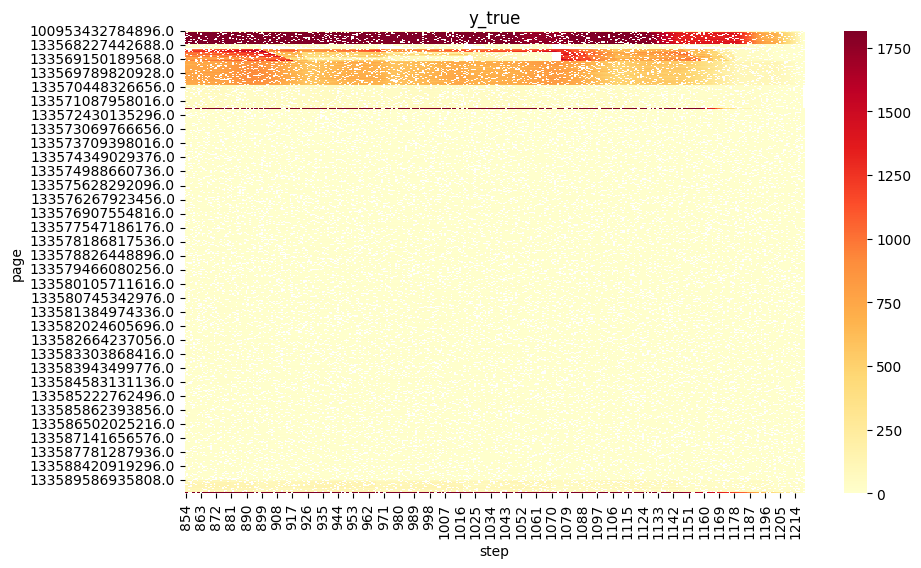

In [12]:
# Pivot directly by page/step (no binning) and plot predicted values
for col in ["y_pred", "y_true"]:
    heatmap_df = graph_df.pivot_table(
        index="page",
        columns="step",
        values=col,
    )
    save_heatmap(
        heatmap_df,
        title=col,
        vmin=graph_df[col].quantile(0.02),
        vmax=graph_df[col].quantile(0.98),
    )